# Data Collection for Heston Calibration

This notebook fetches all required data for the Heston calibration workflow:

1. **Yield Curve** - Treasury rates for risk-free rate interpolation
2. **Historical Spot Prices** - For computing underlying statistics
3. **Current Option Chain** - For calibration

## Data Storage Structure

```
data/
├── raw/
│   ├── rates/                    # Treasury yield curve
│   └── underlying/               # Historical spot prices
│       ├── QQQ_history.csv
│       ├── SPY_history.csv
│       └── TSLA_history.csv
├── processed/
│   └── calibration/              # Filtered options for calibration
│       ├── QQQ_calibration.csv
│       ├── SPY_calibration.csv
│       └── TSLA_calibration.csv
└── models/                       # Trained models (output of main.py)
```

In [1]:
# Auto-reload modules during development
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import yfinance as yf
import json

# Add project root to path
PROJECT_ROOT = Path("..").resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.data_generation import (
    fetch_market_options,
    load_yield_curve,
    fetch_underlying_history
)

# Plotting settings
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

## Configuration

In [2]:
# ============================================================
# CONFIGURATION
# ============================================================

# Tickers to fetch
TICKERS = ['QQQ', 'SPY', 'TSLA']

# Historical data period (years)
HISTORY_YEARS = 2

# Option filtering parameters
FILTERS = {
    'min_volume': 50,           # Minimum trading volume
    'min_open_interest': 100,   # Minimum open interest
    'moneyness_range': (0.90, 1.10),  # Near ATM
    'maturity_range': (0.05, 1.5),    # 3 weeks to 1.5 years
    'option_type': 'call'       # Use calls only
}

# Data directories
DATA_DIR = PROJECT_ROOT / 'data'
RAW_DIR = DATA_DIR / 'raw'
UNDERLYING_DIR = RAW_DIR / 'underlying'
PROCESSED_DIR = DATA_DIR / 'processed'
CALIBRATION_DIR = PROCESSED_DIR / 'calibration'

# Create directories
for d in [UNDERLYING_DIR, CALIBRATION_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print(f"Tickers to fetch: {TICKERS}")
print(f"Historical period: {HISTORY_YEARS} years")
print(f"\nData will be saved to:")
print(f"  Historical: {UNDERLYING_DIR}")
print(f"  Calibration: {CALIBRATION_DIR}")

Tickers to fetch: ['QQQ', 'SPY', 'TSLA']
Historical period: 2 years

Data will be saved to:
  Historical: /Users/jorismrvy/Desktop/TBS MSc/Master Dissertation/Heston Model/data/raw/underlying
  Calibration: /Users/jorismrvy/Desktop/TBS MSc/Master Dissertation/Heston Model/data/processed/calibration


---

## 1. Load Yield Curve

The Nelson-Siegel-Svensson model provides accurate risk-free rates for all maturities.

In [3]:
print("Loading Treasury Yield Curve")
print("=" * 70)

yield_curve = load_yield_curve()

print(f"\nYield Curve Parameters:")
if yield_curve.method == 'nss' and yield_curve.curve is not None:
    print(f"  β0 (level):     {yield_curve.curve.beta0:.6f}")
    print(f"  β1 (slope):     {yield_curve.curve.beta1:.6f}")
    print(f"  β2 (curvature): {yield_curve.curve.beta2:.6f}")
    print(f"  β3 (curvature2): {yield_curve.curve.beta3:.6f}")
    print(f"  τ1 (decay1):    {yield_curve.curve.tau1:.6f}")
    print(f"  τ2 (decay2):    {yield_curve.curve.tau2:.6f}")
else:
    print(f"  Method: {yield_curve.method}")
    print(f"  Using linear interpolation")

print(f"\nSample Risk-Free Rates:")
for tau in [0.25, 0.5, 1.0, 2.0]:
    rate = yield_curve.get_rate(tau)
    print(f"  {tau:.2f} years: {rate:.2%}")

INFO:src.yield_curve:Loading Treasury yields from local CSV: /Users/jorismrvy/Desktop/TBS MSc/Master Dissertation/Heston Model/data/raw/rates/2025-daily-treasury-rates.csv
INFO:src.yield_curve:NSS curve calibrated: NelsonSiegelSvenssonCurve(beta0=np.float64(0.05188879324667761), beta1=np.float64(-0.011203255492937634), beta2=np.float64(-0.02985653565586586), beta3=np.float64(-0.006911688874458273), tau1=np.float64(2.0), tau2=np.float64(5.0))
INFO:src.data_generation:Loaded yield curve with 14 points
INFO:src.data_generation:  Short rate (3m): 0.0395
INFO:src.data_generation:  Medium rate (1y): 0.0371
INFO:src.data_generation:  Long rate (10y): 0.0419


Loading Treasury Yield Curve

Yield Curve Parameters:
  β0 (level):     0.051889
  β1 (slope):     -0.011203
  β2 (curvature): -0.029857
  β3 (curvature2): -0.006912
  τ1 (decay1):    2.000000
  τ2 (decay2):    5.000000

Sample Risk-Free Rates:
  0.25 years: 3.95%
  0.50 years: 3.85%
  1.00 years: 3.71%
  2.00 years: 3.59%


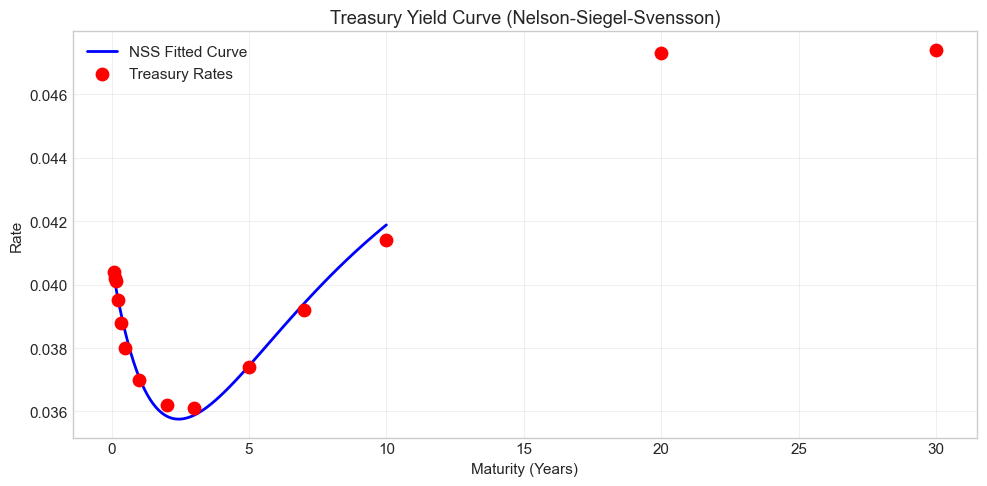

In [4]:
# Plot yield curve
maturities = np.linspace(0.1, 10, 100)
rates = [yield_curve.get_rate(t) for t in maturities]

plt.figure(figsize=(10, 5))
plt.plot(maturities, rates, 'b-', linewidth=2, label='NSS Fitted Curve')

# Plot original Treasury data points if available
if yield_curve.maturities is not None and yield_curve.yields is not None:
    plt.scatter(yield_curve.maturities, yield_curve.yields, 
               color='red', s=80, zorder=5, label='Treasury Rates')

plt.xlabel('Maturity (Years)')
plt.ylabel('Rate')
plt.title('Treasury Yield Curve (Nelson-Siegel-Svensson)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---

## 2. Fetch Data for Each Ticker

For each ticker, we fetch:
1. **Historical spot prices** (2 years) - for underlying statistics
2. **Current option chain** - for calibration

In [5]:
def fetch_and_save_ticker_data(ticker: str, yield_curve, filters: dict) -> dict:
    """
    Fetch all data for a single ticker and save to files.
    
    Returns summary dict.
    """
    print(f"\n{'='*70}")
    print(f"FETCHING: {ticker}")
    print(f"{'='*70}")
    
    summary = {'ticker': ticker, 'timestamp': datetime.now().isoformat()}
    
    # -------------------------------------------------------------------------
    # 1. Fetch Historical Spot Prices
    # -------------------------------------------------------------------------
    print(f"\n[1] Fetching {HISTORY_YEARS} years of historical prices...")
    
    hist_df = fetch_underlying_history(ticker, years=HISTORY_YEARS)
    
    # Save historical data
    hist_file = UNDERLYING_DIR / f'{ticker}_history.csv'
    hist_df.to_csv(hist_file, index=False)
    
    summary['history'] = {
        'file': str(hist_file),
        'n_observations': len(hist_df),
        'date_range': [str(hist_df['Date'].min().date()), str(hist_df['Date'].max().date())],
        'price_range': [float(hist_df['Close'].min()), float(hist_df['Close'].max())]
    }
    
    print(f"    Saved: {hist_file}")
    print(f"    Observations: {len(hist_df)}")
    print(f"    Price range: ${hist_df['Close'].min():.2f} - ${hist_df['Close'].max():.2f}")
    
    # -------------------------------------------------------------------------
    # 2. Fetch Current Options
    # -------------------------------------------------------------------------
    print(f"\n[2] Fetching current option chain...")
    
    options_df = fetch_market_options(
        ticker=ticker,
        min_volume=filters['min_volume'],
        min_oi=filters['min_open_interest'],
        use_yield_curve=True
    )
    
    print(f"    Retrieved {len(options_df)} total options")
    print(f"    Spot: ${options_df['spot'].iloc[0]:.2f}")
    
    summary['spot'] = float(options_df['spot'].iloc[0])
    summary['options_raw'] = len(options_df)
    
    # -------------------------------------------------------------------------
    # 3. Filter for Calibration
    # -------------------------------------------------------------------------
    print(f"\n[3] Filtering for calibration...")
    
    calib_df = options_df[
        (options_df['type'] == filters['option_type']) &
        (options_df['moneyness'] >= filters['moneyness_range'][0]) &
        (options_df['moneyness'] <= filters['moneyness_range'][1]) &
        (options_df['tau'] >= filters['maturity_range'][0]) &
        (options_df['tau'] <= filters['maturity_range'][1])
    ].copy()
    
    # Add underlying column for reference
    calib_df['underlying'] = ticker
    
    # Save calibration data
    calib_file = CALIBRATION_DIR / f'{ticker}_calibration.csv'
    calib_df.to_csv(calib_file, index=False)
    
    summary['calibration'] = {
        'file': str(calib_file),
        'n_options': len(calib_df),
        'moneyness_range': [float(calib_df['moneyness'].min()), float(calib_df['moneyness'].max())],
        'maturity_range': [float(calib_df['tau'].min()), float(calib_df['tau'].max())]
    }
    
    print(f"    Saved: {calib_file}")
    print(f"    Calibration options: {len(calib_df)}")
    print(f"    Moneyness: {calib_df['moneyness'].min():.3f} - {calib_df['moneyness'].max():.3f}")
    print(f"    Maturity: {calib_df['tau'].min():.2f} - {calib_df['tau'].max():.2f} years")
    
    return summary, hist_df, calib_df

In [6]:
# Fetch all tickers
all_summaries = {}
all_history = {}
all_calibration = {}

for ticker in TICKERS:
    try:
        summary, hist_df, calib_df = fetch_and_save_ticker_data(ticker, yield_curve, FILTERS)
        all_summaries[ticker] = summary
        all_history[ticker] = hist_df
        all_calibration[ticker] = calib_df
    except Exception as e:
        print(f"\nERROR fetching {ticker}: {e}")
        import traceback
        traceback.print_exc()

INFO:src.data_generation:Fetching 2 years of historical data for QQQ...



FETCHING: QQQ

[1] Fetching 2 years of historical prices...


INFO:src.data_generation:  Retrieved 501 daily observations
INFO:src.data_generation:  Date range: 2023-11-30 to 2025-11-28
INFO:src.data_generation:  Price range: $380.37 - $635.77
INFO:src.data_generation:Fetching option data for QQQ...
INFO:src.yield_curve:NSS curve calibrated: NelsonSiegelSvenssonCurve(beta0=np.float64(0.05188879324667761), beta1=np.float64(-0.011203255492937634), beta2=np.float64(-0.02985653565586586), beta3=np.float64(-0.006911688874458273), tau1=np.float64(2.0), tau2=np.float64(5.0))
INFO:src.data_generation:Loaded yield curve with 14 points
INFO:src.data_generation:  Short rate (3m): 0.0395
INFO:src.data_generation:  Medium rate (1y): 0.0371
INFO:src.data_generation:  Long rate (10y): 0.0419
INFO:src.data_generation:Using yield curve for risk-free rates


    Saved: /Users/jorismrvy/Desktop/TBS MSc/Master Dissertation/Heston Model/data/raw/underlying/QQQ_history.csv
    Observations: 501
    Price range: $380.37 - $635.77

[2] Fetching current option chain...


INFO:src.data_generation:Found 31 expiration dates
INFO:src.data_generation:Successfully fetched 417 option quotes
INFO:src.data_generation:  Calls: 193
INFO:src.data_generation:  Puts: 224
INFO:src.data_generation:  Maturities: 0.03 to 2.15 years
INFO:src.data_generation:  Strikes: 189.78 to 915.00
INFO:src.data_generation:  Current spot: $619.25
INFO:src.data_generation:Fetching 2 years of historical data for SPY...


...

    Saved: /Users/jorismrvy/Desktop/TBS MSc/Master Dissertation/Heston Model/data/raw/underlying/SPY_history.csv
    Observations: 501
    Price range: $443.30 - $687.39

[2] Fetching current option chain...


INFO:src.data_generation:Found 31 expiration dates
INFO:src.data_generation:Successfully fetched 644 option quotes
INFO:src.data_generation:  Calls: 256
INFO:src.data_generation:  Puts: 388
INFO:src.data_generation:  Maturities: 0.03 to 2.15 years
INFO:src.data_generation:  Strikes: 50.00 to 1340.00
INFO:src.data_generation:  Current spot: $683.47
INFO:src.data_generation:Fetching 2 years of historical data for TSLA...
INFO:src.data_generation:  Retrieved 501 daily observations
INFO:src.data_generation:  Date range: 2023-11-30 to 2025-11-28
INFO:src.data_generation:  Price range: $142.05 - $479.86
INFO:src.data_generation:Fetching option data for TSLA...
INFO:src.yield_curve:NSS curve calibrated: NelsonSiegelSvenssonCurve(beta0=np.float64(0.05188879324667761), beta1=np.float64(-0.011203255492937634), beta2=np.float64(-0.02985653565586586), beta3=np.float64(-0.006911688874458273), tau1=np.float64(2.0), tau2=np.float64(5.0))
INFO:src.data_generation:Loaded yield curve with 14 points
INFO

    Retrieved 644 total options
    Spot: $683.47

[3] Filtering for calibration...
    Saved: /Users/jorismrvy/Desktop/TBS MSc/Master Dissertation/Heston Model/data/processed/calibration/SPY_calibration.csv
    Calibration options: 134
    Moneyness: 0.914 - 1.097
    Maturity: 0.06 - 1.30 years

FETCHING: TSLA

[1] Fetching 2 years of historical prices...
    Saved: /Users/jorismrvy/Desktop/TBS MSc/Master Dissertation/Heston Model/data/raw/underlying/TSLA_history.csv
    Observations: 501
    Price range: $142.05 - $479.86

[2] Fetching current option chain...


INFO:src.data_generation:Found 20 expiration dates
INFO:src.data_generation:Successfully fetched 361 option quotes
INFO:src.data_generation:  Calls: 193
INFO:src.data_generation:  Puts: 168
INFO:src.data_generation:  Maturities: 0.04 to 2.15 years
INFO:src.data_generation:  Strikes: 5.00 to 960.00
INFO:src.data_generation:  Current spot: $430.17


    Retrieved 361 total options
    Spot: $430.17

[3] Filtering for calibration...
    Saved: /Users/jorismrvy/Desktop/TBS MSc/Master Dissertation/Heston Model/data/processed/calibration/TSLA_calibration.csv
    Calibration options: 47
    Moneyness: 0.930 - 1.093
    Maturity: 0.06 - 1.13 years


---

## 3. Data Summary

In [7]:
# Summary table
print("\n" + "=" * 70)
print("DATA COLLECTION SUMMARY")
print("=" * 70)

print(f"\n{'Ticker':<8} {'Spot':>10} {'History':>12} {'Options':>10} {'Calib':>10}")
print("-" * 52)

for ticker, summary in all_summaries.items():
    print(f"{ticker:<8} ${summary['spot']:>9.2f} "
          f"{summary['history']['n_observations']:>12,} "
          f"{summary['options_raw']:>10,} "
          f"{summary['calibration']['n_options']:>10,}")


DATA COLLECTION SUMMARY

Ticker         Spot      History    Options      Calib
----------------------------------------------------
QQQ      $   619.25          501        417        107
SPY      $   683.47          501        644        134
TSLA     $   430.17          501        361         47


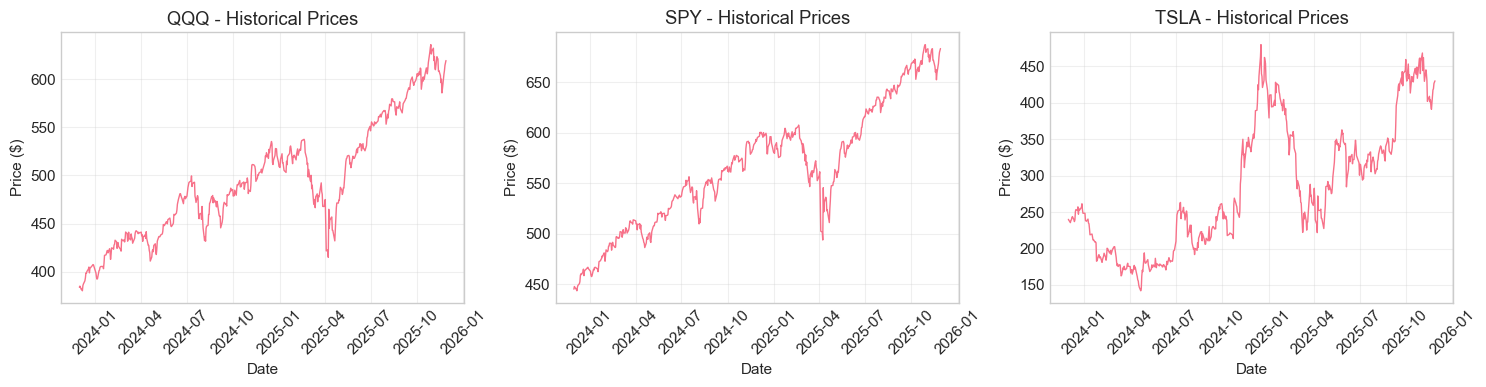

Chart saved to: /Users/jorismrvy/Desktop/TBS MSc/Master Dissertation/Heston Model/data/raw/underlying/historical_prices.png


In [8]:
# Visualize historical prices
n_tickers = len(all_history)
fig, axes = plt.subplots(1, n_tickers, figsize=(5*n_tickers, 4))

if n_tickers == 1:
    axes = [axes]

for ax, (ticker, hist_df) in zip(axes, all_history.items()):
    ax.plot(hist_df['Date'], hist_df['Close'], linewidth=1)
    ax.set_title(f'{ticker} - Historical Prices')
    ax.set_xlabel('Date')
    ax.set_ylabel('Price ($)')
    ax.grid(True, alpha=0.3)
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig(UNDERLYING_DIR / 'historical_prices.png', dpi=150)
plt.show()
print(f"Chart saved to: {UNDERLYING_DIR / 'historical_prices.png'}")

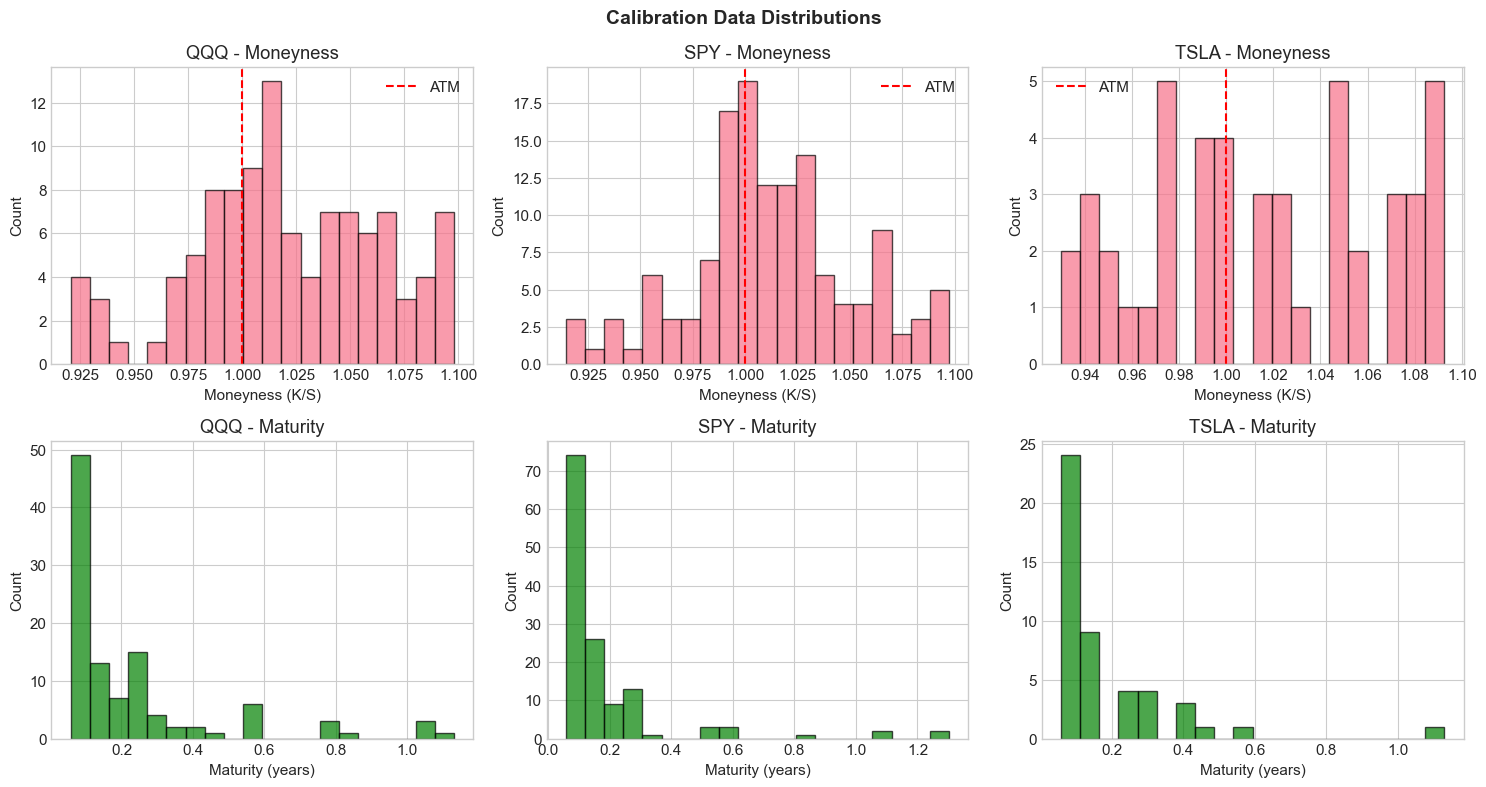

Chart saved to: /Users/jorismrvy/Desktop/TBS MSc/Master Dissertation/Heston Model/data/processed/calibration/calibration_distributions.png


In [9]:
# Visualize calibration data
fig, axes = plt.subplots(2, n_tickers, figsize=(5*n_tickers, 8))

if n_tickers == 1:
    axes = axes.reshape(-1, 1)

for col, (ticker, calib_df) in enumerate(all_calibration.items()):
    # Moneyness distribution
    axes[0, col].hist(calib_df['moneyness'], bins=20, edgecolor='black', alpha=0.7)
    axes[0, col].axvline(1.0, color='red', linestyle='--', label='ATM')
    axes[0, col].set_xlabel('Moneyness (K/S)')
    axes[0, col].set_ylabel('Count')
    axes[0, col].set_title(f'{ticker} - Moneyness')
    axes[0, col].legend()
    
    # Maturity distribution
    axes[1, col].hist(calib_df['tau'], bins=20, edgecolor='black', alpha=0.7, color='green')
    axes[1, col].set_xlabel('Maturity (years)')
    axes[1, col].set_ylabel('Count')
    axes[1, col].set_title(f'{ticker} - Maturity')

plt.suptitle('Calibration Data Distributions', fontsize=14, fontweight='bold')
plt.tight_layout()
# Save in the same folder as calibration data
plt.savefig(CALIBRATION_DIR / 'calibration_distributions.png', dpi=150)
plt.show()
print(f"Chart saved to: {CALIBRATION_DIR / 'calibration_distributions.png'}")

---

## 4. Save Metadata

In [10]:
# Save collection metadata
metadata = {
    'collection_timestamp': datetime.now().isoformat(),
    'tickers': TICKERS,
    'history_years': HISTORY_YEARS,
    'filters': FILTERS,
    'summaries': all_summaries
}

metadata_file = DATA_DIR / 'collection_metadata.json'
with open(metadata_file, 'w') as f:
    json.dump(metadata, f, indent=2, default=str)

print(f"Metadata saved to: {metadata_file}")

Metadata saved to: /Users/jorismrvy/Desktop/TBS MSc/Master Dissertation/Heston Model/data/collection_metadata.json


In [11]:
tickers_str = ' '.join(TICKERS)
print(f"\n{'='*70}")
print("READY FOR CALIBRATION")
print(f"{'='*70}")
print(f"\nRun the following command from the project root:")
print(f"\n    python main.py --tickers {tickers_str}")
print(f"\nFiles saved:")
for ticker in TICKERS:
    print(f"  - {UNDERLYING_DIR / f'{ticker}_history.csv'}")
    print(f"  - {CALIBRATION_DIR / f'{ticker}_calibration.csv'}")


READY FOR CALIBRATION

Run the following command from the project root:

    python main.py --tickers QQQ SPY TSLA

Files saved:
  - /Users/jorismrvy/Desktop/TBS MSc/Master Dissertation/Heston Model/data/raw/underlying/QQQ_history.csv
  - /Users/jorismrvy/Desktop/TBS MSc/Master Dissertation/Heston Model/data/processed/calibration/QQQ_calibration.csv
  - /Users/jorismrvy/Desktop/TBS MSc/Master Dissertation/Heston Model/data/raw/underlying/SPY_history.csv
  - /Users/jorismrvy/Desktop/TBS MSc/Master Dissertation/Heston Model/data/processed/calibration/SPY_calibration.csv
  - /Users/jorismrvy/Desktop/TBS MSc/Master Dissertation/Heston Model/data/raw/underlying/TSLA_history.csv
  - /Users/jorismrvy/Desktop/TBS MSc/Master Dissertation/Heston Model/data/processed/calibration/TSLA_calibration.csv
